# Setup & Motivation

Before we talk about what a universal differential equation is, let's earn the
right to care about one.

In this notebook you'll take a conceptual rainfall-runoff model — the kind you
have almost certainly calibrated before — and calibrate it two ways: the way
you do it today, and by computing the gradient of your objective function with
respect to its parameters. Then we'll look hard at when the second way is
worth the trouble, because at this size it isn't.

That last point matters. If the pitch for differentiable modeling were "it's
faster," you'd be right to be skeptical. The real argument is about what
becomes *possible*, and it only shows up when you stop asking for a handful of
numbers and start asking for a function.

:::{admonition} Time check — 10 minutes
:class: tip
By the end you'll be able to:
- confirm your environment works (do this now, not at minute 40)
- write a conceptual hydrologic model that PyTorch can differentiate
- calibrate it by gradient descent, and say honestly when that's worth doing
- explain why training 16 basins costs the same as training one
:::

## Motivation

You already own a working calibration workflow. SCE-UA, DDS, a differential
evolution wrapper, something. It works. So the honest question is: what does
differentiability buy that your current workflow can't get?

The answer is *dimensionality*. Derivative-free search degrades badly as the
number of parameters grows; gradient descent barely notices. That difference
is what makes it reasonable to put a neural network — tens of thousands of
weights — inside a water balance and fit the whole thing at once. We'll
measure both sides of that today rather than asserting it.

## What we'll cover

1. Setup check
2. The basin
3. A model you already know, written differentiably
4. Calibration the way you do it now
5. The same model, by gradient descent
6. The wall that derivative-free search hits
7. The thing that actually scales

In [1]:
# --- Colab bootstrap: installs the workshop package on first run -----------
try:
    import workshop_utils
except ImportError:
    %pip install -q "git+https://github.com/BennettHydroLab/differentiable_modeling_workshop.git"
    import workshop_utils

In [2]:
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from workshop_utils import nse, summary, hydrograph, set_style, COLORS, ParamMap
from workshop_utils.data import (
    load_basin, split_by_water_year, BASIN_TEMPERATE, BASIN_LABELS,
)

set_style()
torch.manual_seed(0)

print(f"torch {torch.__version__}")
print("Setup OK — if this printed, you're ready.")

torch 2.14.0+cu130
Setup OK — if this printed, you're ready.


## 1. The basin

We'll use `minicamels`: 50 CAMELS-US basins, 30 water years of Daymet forcings
and USGS streamflow, small enough to pull down in a couple of seconds.

Our running example is the Cowpasture River in Virginia — humid, essentially
snow-free, and well behaved. We want the hydrology to be uncomplicated so the
*method* is the only thing in the room. Later notebooks move to a snow-dominated
basin and a semi-arid one, where things get harder.

In [3]:
ds = load_basin(BASIN_TEMPERATE)

print(BASIN_LABELS[BASIN_TEMPERATE])
print(f"period     : {str(ds.time.values[0])[:10]} to {str(ds.time.values[-1])[:10]}")
print(f"variables  : {list(ds.data_vars)}")
print(f"mean precip: {float(ds.prcp.mean()):.2f} mm/day")
print(f"mean PET   : {float(ds.pet.mean()):.2f} mm/day")
print(f"mean flow  : {float(ds.qobs.mean()):.2f} mm/day")

Cowpasture River, VA (humid temperate)
period     : 1980-10-01 to 2010-09-30
variables  : ['prcp', 'tmax', 'tmin', 'srad', 'vp', 'qobs', 'tmean', 'pet']
mean precip: 3.10 mm/day
mean PET   : 2.57 mm/day
mean flow  : 1.14 mm/day


A note on PET, because it's the first place a hidden assumption could bite you.
CAMELS ships no PET time series — only a long-term mean. `load_basin` computes
a Hamon PET from daily temperature and then **rescales it per basin** so its
long-term mean matches the CAMELS-reported value. Raw Hamon underestimates that
target by a factor ranging from about 1.2 to 2.2 across the 50 basins, worst in
cold catchments, so a single global correction wouldn't do.

It's a crude PET. It knows nothing about wind, humidity, or vegetation. We're
using it because it needs only what CAMELS gives us, and because calibrated
parameters absorb a lot of PET error. Worth remembering when you interpret a
calibrated parameter as a physical quantity.

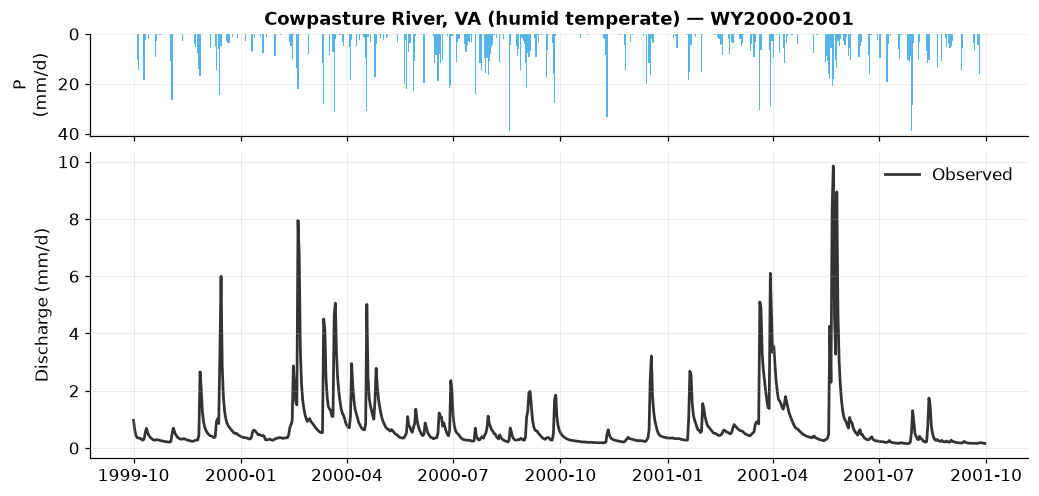

In [4]:
window = slice("1999-10-01", "2001-09-30")
sub = ds.sel(time=window)

hydrograph(
    sub.time.values,
    obs=sub.qobs.values,
    precip=sub.prcp.values,
    title=f"{BASIN_LABELS[BASIN_TEMPERATE]} — WY2000-2001",
)
plt.show()

## 2. A model you already know

Here's an HBV-style conceptual model: one soil-moisture store feeding a fast
and a slow linear reservoir. Six parameters. Nothing exotic — the point is that
this is an ordinary model, not a machine learning object.

Two things about how it's written are worth your attention, because they're the
entire trick:

**Everything is a `torch` operation.** Not numpy. That's what lets PyTorch
record what happened and replay it backwards.

**The parameters carry a leading batch dimension.** `theta` has shape
`(n_parameter_sets, 6)`, and every state variable is a vector rather than a
scalar. The only loop is over time. We'll cash that in at the end of the
notebook, and it turns out to matter more than anything else here.

In the notation we'll use all workshop (see `resources/research_brief.md`):
`u` is the state vector, `x` the forcings, `theta` the physical parameters.

In [5]:
PARAM_NAMES = ["FC", "beta", "LP", "K_fast", "K_slow", "PERC"]

# Physical bounds. ParamMap squashes an unconstrained real number through a
# sigmoid onto these ranges, so the optimizer gets a free hand while the
# physics never sees a negative field capacity.
LO = torch.tensor([ 50., 1.0, 0.3, 0.05, 0.005, 0.1])
HI = torch.tensor([500., 5.0, 1.0, 0.60, 0.150, 3.0])
pmap = ParamMap(LO, HI)


def simulate(P, E, theta, u0=(50., 5., 20.)):
    """HBV-lite rainfall-runoff.

    P, E   : (time,) precipitation and PET, mm/day
    theta  : (n, 6) parameter sets
    returns: (n, time) simulated discharge, mm/day

    Batched over the leading parameter dimension — the loop is over time only.
    """
    FC, beta, LP, K_fast, K_slow, PERC = theta.T
    n = theta.shape[0]

    # State u = (soil store, fast reservoir, slow reservoir)
    S_soil = torch.full((n,), u0[0])
    S_fast = torch.full((n,), u0[1])
    S_slow = torch.full((n,), u0[2])

    discharge = []
    for t in range(P.shape[0]):
        # Fraction of rainfall that becomes recharge rises nonlinearly with
        # wetness — this is HBV's characteristic beta-curve.
        wetness = torch.clamp(S_soil / FC, 0., 1.)
        recharge = P[t] * wetness ** beta

        # ET shuts down as the soil dries, linearly below a threshold LP*FC.
        et = E[t] * torch.clamp(S_soil / (LP * FC), 0., 1.)
        S_soil = torch.clamp(S_soil + P[t] - recharge - et, min=0.)

        # Percolation moves water from the fast store to the slow one,
        # capped at a constant rate.
        perc = torch.minimum(PERC, S_fast)

        S_fast = S_fast + recharge - perc
        q_fast = K_fast * S_fast
        S_fast = S_fast - q_fast

        S_slow = S_slow + perc
        q_slow = K_slow * S_slow
        S_slow = S_slow - q_slow

        discharge.append(q_fast + q_slow)

    return torch.stack(discharge, dim=1)

### Splitting the data

We split **in time**, by water year, and we prepend a year of spin-up to each
period.

Both halves of that sentence matter. Splitting in time — rather than shuffling
days into random train and test sets — is the difference between an honest
evaluation and a meaningless one: adjacent days in a hydrograph are nearly the
same day, so a random split lets the model memorize its way to a beautiful
score. The spin-up year exists because the model starts from a guessed soil
moisture, and you don't want that guess scored. We simulate it and throw it
away.

In [6]:
SPINUP = 365
split = split_by_water_year(ds, train=(1998, 1999), test=(2000, 2002), spinup_days=SPINUP)


def arrays(d):
    return (
        torch.tensor(d.prcp.values, dtype=torch.float32),
        torch.tensor(d.pet.values, dtype=torch.float32),
        torch.tensor(d.qobs.values, dtype=torch.float32),
    )


P, E, Q = arrays(split["train"])
P_test, E_test, Q_test = arrays(split["test"])

print(f"train: {len(P)} days ({SPINUP} of them spin-up)")
print(f"test : {len(P_test)} days ({SPINUP} of them spin-up)")

train: 1095 days (365 of them spin-up)
test : 1461 days (365 of them spin-up)


## 3. Calibration the way you do it now

Throw a few hundred parameter sets at the model and keep the best one. This is
the honest baseline: it's what every derivative-free method is doing underneath,
just with a smarter proposal distribution.

Note `torch.no_grad()`. We're not asking for gradients, so we don't pay for the
graph — and the result is that 500 complete three-year simulations run in about
a tenth of a second.

In [7]:
t0 = time.time()

with torch.no_grad():
    raw = torch.randn(500, 6) * 1.5
    sim = simulate(P, E, pmap(raw))
    scores = 1 - ((sim[:, SPINUP:] - Q[SPINUP:]) ** 2).sum(1) / (
        (Q[SPINUP:] - Q[SPINUP:].mean()) ** 2
    ).sum()

t_random = time.time() - t0
best = scores.argmax()

print(f"500 parameter sets in {t_random:.2f} s")
print(f"best NSE   : {scores[best]:.3f}")
print(f"median NSE : {scores.median():.3f}")

500 parameter sets in 0.15 s
best NSE   : 0.643
median NSE : 0.523


## 4. The same model, by gradient descent

Now the different thing. Rather than *sampling* parameter sets, we ask PyTorch
a question no sampler can answer: **which way should each parameter move to
reduce the loss?**

Nothing about the model changes. We wrote it in torch operations, so the
gradient is already available — we just have to ask for it. That is the whole
content of "differentiable modeling" at this stage: there's no neural network
here, no machine learning. Just a hydrologic model whose derivative we can
compute.

In [8]:
t0 = time.time()

raw_g = torch.zeros(1, 6, requires_grad=True)
opt = torch.optim.Adam([raw_g], lr=0.25)

history = []
for step in range(40):
    opt.zero_grad()
    q_sim = simulate(P, E, pmap(raw_g))[0]
    loss = -nse(q_sim[SPINUP:], Q[SPINUP:])   # maximize NSE == minimize -NSE
    loss.backward()
    opt.step()
    history.append(-loss.item())
    if step % 10 == 0:
        print(f"  step {step:3d}   NSE {-loss.item():.3f}")

t_grad = time.time() - t0
theta_cal = pmap(raw_g).detach()

print(f"\n{len(history)} gradient steps in {t_grad:.1f} s ({t_grad/len(history):.2f} s/step)")
print(f"final NSE: {history[-1]:.3f}")

  step   0   NSE 0.614


  step  10   NSE 0.627


  step  20   NSE 0.631


  step  30   NSE 0.634



40 gradient steps in 38.4 s (0.96 s/step)
final NSE: 0.635


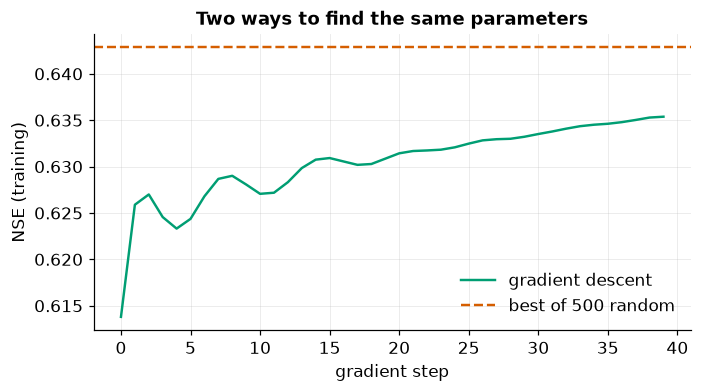

  FC        198.558
  beta        4.560
  LP          0.897
  K_fast      0.322
  K_slow      0.028
  PERC        1.455


In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(history, color=COLORS["hybrid"], label="gradient descent")
ax.axhline(scores[best], color=COLORS["ml"], ls="--", label=f"best of 500 random")
ax.set_xlabel("gradient step")
ax.set_ylabel("NSE (training)")
ax.set_title("Two ways to find the same parameters")
ax.legend()
plt.show()

for name, value in zip(PARAM_NAMES, theta_cal[0].tolist()):
    print(f"  {name:8s} {value:8.3f}")

Those are physically sensible numbers — a field capacity around 200 mm, a fast
reservoir draining an order of magnitude quicker than the slow one. That's
`ParamMap` doing its job: whatever the optimizer proposes, the physics only
ever sees a value inside its stated range.

Let's score the calibrated model on the held-out years.

Held-out test period (WY2000-2002):
  NSE        0.526
  KGE        0.654
  logNSE     0.283
  PBIAS      7.471
  RMSE       0.717


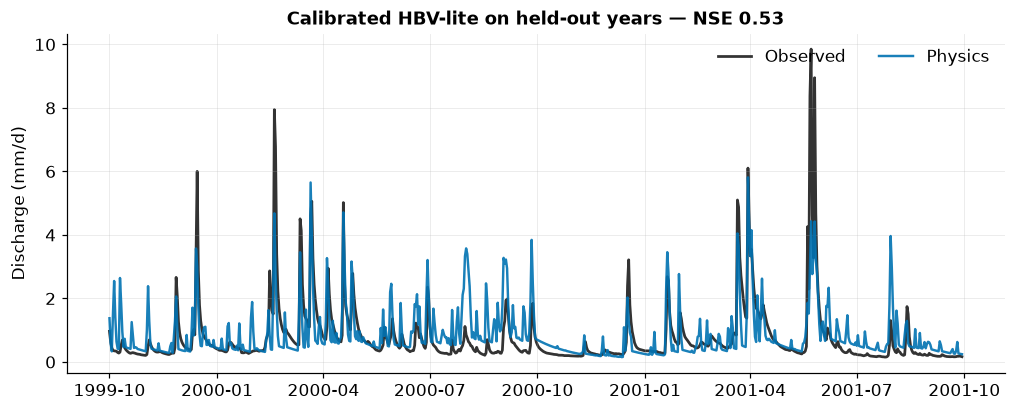

In [10]:
with torch.no_grad():
    q_test = simulate(P_test, E_test, theta_cal)[0]

metrics = summary(q_test[SPINUP:], Q_test[SPINUP:])
print("Held-out test period (WY2000-2002):")
for k, v in metrics.items():
    print(f"  {k:8s} {v:7.3f}")

show = slice(SPINUP, SPINUP + 730)
hydrograph(
    split["test"].time.values[show],
    obs=Q_test[show].numpy(),
    physics=q_test[show].numpy(),
    title=f"Calibrated HBV-lite on held-out years — NSE {metrics['NSE']:.2f}",
)
plt.show()

## 5. So was that worth it?

Put the two side by side honestly.

In [11]:
print(f"{'method':<28}{'cost':>10}{'train NSE':>12}")
print("-" * 50)
print(f"{'random search (500 sets)':<28}{t_random:>9.2f}s{scores[best]:>12.3f}")
print(f"{'gradient descent (40 steps)':<28}{t_grad:>9.1f}s{history[-1]:>12.3f}")

method                            cost   train NSE
--------------------------------------------------
random search (500 sets)         0.15s       0.643
gradient descent (40 steps)      38.4s       0.635


**Random search won.** It found a slightly better score in a fraction of the
time.

That is not a typo and we're not going to hide it. With six parameters, the
gradient costs more than it's worth. Each gradient step has to build and walk
back through a graph spanning 1,095 sequential timesteps, which is why it runs
about 0.86 s per step while a forward-only simulation costs well under a
millisecond. If someone tells you differentiable modeling is faster than SCE-UA
on a six-parameter bucket model, they haven't measured it.

So why is anyone excited?

Because of how the two lines behave as you add parameters:

| Parameters | Random/grid search | Gradient descent |
|---|---|---|
| 6 | fine — you just saw it win | works, costs more |
| 13 | a 30-point grid is 30¹³ ≈ 1.6 × 10¹⁹ runs | same cost per step |
| 19,208 | not a thing you can do | same cost per step |

That last row isn't hypothetical. It's the size of a one-layer LSTM with 64
hidden units emitting eight SNOW-17 parameters — the architecture in
{cite}`lamichhane2025dynamic`. Reverse-mode automatic differentiation returns
**every** partial derivative for roughly the cost of one extra forward pass,
whether there are six of them or twenty thousand. Derivative-free search has
no equivalent move; as {cite}`shen2023differentiable` put it, estimating
gradients by finite differences over 10,000 weights "would require 10,001
forward model evaluations."

The point isn't that gradients are fast. It's that **gradients are the only
thing that still works once the question mark moves from a handful of numbers
to a function.** That's the whole workshop, and it's where we're going next.

## 6. The thing that actually scales

One more measurement, because it's the one that surprises people.

We wrote `simulate` with a leading batch dimension. So far we've used it for
500 random parameter sets. Now let's use it for something else: **16 different
basins, each with its own parameter vector, trained simultaneously under one
loss.**

In [12]:
from minicamels import MiniCamels

basin_ids = list(MiniCamels().attributes().index)[:16]

cols = [arrays(split_by_water_year(load_basin(b), train=(1998, 1999),
                                   test=(2005, 2005), spinup_days=SPINUP)["train"])
        for b in basin_ids]

P_multi = torch.stack([c[0] for c in cols], dim=1)   # (time, basin)
E_multi = torch.stack([c[1] for c in cols], dim=1)
Q_multi = torch.stack([c[2] for c in cols], dim=1)

print(f"{len(basin_ids)} basins, forcing shape {tuple(P_multi.shape)} (time, basin)")

16 basins, forcing shape (1095, 16) (time, basin)


In [13]:
def simulate_multi(P, E, theta, u0=(50., 5., 20.)):
    """Same model, one parameter vector per basin. P, E: (time, basin)."""
    FC, beta, LP, K_fast, K_slow, PERC = theta.T
    n = theta.shape[0]
    S_soil = torch.full((n,), u0[0])
    S_fast = torch.full((n,), u0[1])
    S_slow = torch.full((n,), u0[2])

    discharge = []
    for t in range(P.shape[0]):
        wetness = torch.clamp(S_soil / FC, 0., 1.)
        recharge = P[t] * wetness ** beta
        et = E[t] * torch.clamp(S_soil / (LP * FC), 0., 1.)
        S_soil = torch.clamp(S_soil + P[t] - recharge - et, min=0.)

        perc = torch.minimum(PERC, S_fast)
        S_fast = S_fast + recharge - perc
        q_fast = K_fast * S_fast
        S_fast = S_fast - q_fast

        S_slow = S_slow + perc
        q_slow = K_slow * S_slow
        S_slow = S_slow - q_slow

        discharge.append(q_fast + q_slow)

    return torch.stack(discharge)     # (time, basin)


t0 = time.time()
raw_m = torch.zeros(16, 6, requires_grad=True)
opt_m = torch.optim.Adam([raw_m], lr=0.25)

for step in range(40):
    opt_m.zero_grad()
    q = simulate_multi(P_multi, E_multi, pmap(raw_m))
    num = ((q[SPINUP:] - Q_multi[SPINUP:]) ** 2).sum(0)
    den = ((Q_multi[SPINUP:] - Q_multi[SPINUP:].mean(0)) ** 2).sum(0)
    loss = (num / den).mean()          # mean of (1 - NSE) across basins
    loss.backward()
    opt_m.step()

t_multi = time.time() - t0

with torch.no_grad():
    q = simulate_multi(P_multi, E_multi, pmap(raw_m))
    num = ((q[SPINUP:] - Q_multi[SPINUP:]) ** 2).sum(0)
    den = ((Q_multi[SPINUP:] - Q_multi[SPINUP:].mean(0)) ** 2).sum(0)
    nse_multi = 1 - num / den

print(f"16 basins, 40 steps : {t_multi:.1f} s ({t_multi/40:.2f} s/step)")
print(f" 1 basin,  40 steps : {t_grad:.1f} s ({t_grad/40:.2f} s/step)")
print(f"\n-> {16}x the work for {t_multi/t_grad:.2f}x the time")
print(f"median NSE across the 16 basins: {nse_multi.median():.3f}")

16 basins, 40 steps : 30.4 s (0.76 s/step)
 1 basin,  40 steps : 38.4 s (0.96 s/step)

-> 16x the work for 0.79x the time
median NSE across the 16 basins: 0.611


Sixteen times the work, and it took **no longer than one basin**.

The reason is that the expensive part of a gradient step — the Python loop over
1,095 timesteps and the autograd graph it builds — is paid once no matter how
wide the batch is. Everything inside the loop is a vector operation. Adding
basins makes those vectors longer, which costs essentially nothing.

This is the real foundation under continental-scale differentiable modeling,
and it's easy to miss. It isn't that gradients are fast. It's that **the cost
doesn't grow when you add basins** — so you can put one model, with one set of
shared weights, across hundreds of catchments and train it under a single loss.
When we get to {cite}`tsai2021calibration` and regionalization in the
applications notebooks, this measurement is why any of it is possible.

## Your turn

Try one of these — five minutes, and both are a single-line change.

1. Rerun the gradient calibration from a different starting point
   (`raw_g = torch.randn(1, 6) * 0.5` instead of zeros). Does it land on the
   same parameters? On the same NSE? What does the answer tell you about
   equifinality in this model?
2. Swap the basin to `BASIN_ARID` (Cedar Creek, ND — runoff ratio 0.04) and
   recalibrate. How much worse does the model do, and which parameters move?

:::{dropdown} Solution — what you should see
**1.** Different starting points usually reach a similar NSE with visibly
different parameter sets, especially `FC` and `PERC`. That's equifinality, and
gradients don't fix it: the gradient tells you a direction downhill, not
whether the valley you're in is the only one. Notebook
`06_practical_guide` comes back to this.

**2.** Much worse — NSE typically drops sharply. A semi-arid basin converts
about 4% of its precipitation to runoff, so the model is being asked to
predict a small residual between two large, uncertain fluxes, and the crude
Hamon PET matters much more. `beta` tends to go high, throttling recharge.
This is a good illustration of the point that a model structure is fit to a
climate as much as to a catchment.
:::

## Takeaways

- A conceptual hydrologic model written in torch operations is differentiable
  for free — no neural network required. That alone gives you gradient-based
  calibration.
- At six parameters, **gradient descent loses to random search**. Be suspicious
  of anyone claiming otherwise; the gradient's advantage is dimensional, not
  constant-factor.
- Reverse-mode AD returns every partial derivative for about the cost of one
  extra forward pass, which is why a 19,208-weight network inside a water
  balance is tractable and a 19,208-parameter grid search is not.
- Batching is nearly free: 16 basins cost the same as one. This — not raw
  speed — is what makes regional and continental differentiable modeling work.
- Split in time, by water year, and spin the model up. A random split over days
  will flatter your model into meaninglessness.

## Where next

`theory/01_gradients_and_autodiff` opens up what `.backward()` actually did,
and how to keep a gradient alive through the `min` and threshold operations
that conceptual models are full of. Then
`theory/02_neural_odes_and_udes` introduces the framework that lets you
replace a *process* rather than tune a *number*.

## References

```{bibliography}
:filter: docname in docnames
```